In [2]:
import os 
import numpy as np
import pandas as pd 
import torchvision 
import ast
import re
import cv2 
import seaborn as sns
from statistics import mean
import matplotlib.pyplot as plt
from collections import Counter

In [29]:
pr_epochs = pd.read_csv(r'epochs\Precision_Recall_Epochs.csv')
pr_epochs

,Epoch,1,2,3,4,5,6,7,8,9,10
0,Class 1,"(0.40845191153780214, 0.9031463229719484)","(0.5821856094735487, 0.8572782410917361)","(0.5167748322516775, 0.8904473085670963)","(0.5226004158914305, 0.9050416982562547)","(0.5279846535770706, 0.8868460955269143)","(0.568516699410609, 0.8775587566338134)","(0.45377832559021525, 0.9071266110689916)","(0.5194438409732783, 0.9063684609552691)","(0.5291797192249681, 0.8644806671721)","(0.4562631881833877, 0.9016300227445034)"
1,Class 2,"(0.4933046935697637, 0.9297958480489276)","(0.5112377926265128, 0.9424584374192437)","(0.5075465564482422, 0.9414247566543199)","(0.5608364032584444, 0.9310879490050823)","(0.4969890510948905, 0.9384098544232923)","(0.5448272413620681, 0.9385821345507795)","(0.48698851399856424, 0.9349642518735464)","(0.5306122448979592, 0.9294512877939529)","(0.47174872371722765, 0.9392712550607287)","(0.5608527962288408, 0.9018864673959859)"
2,Class 3,"(0.4103051982647081, 0.9452919516044187)","(0.4562689585439838, 0.9495002630194634)","(0.4945968412302577, 0.9389794844818516)","(0.5329359466558901, 0.924951779765036)","(0.5073133179368745, 0.9244257408381553)","(0.5161485668146952, 0.8967210240224444)","(0.5811672967863895, 0.862528493775206)","(0.552849018134993, 0.9033841837629318)","(0.43432799806965333, 0.9468700683850605)","(0.591824502517382, 0.8656847273364896)"
3,Class 4,"(0.38676933846692335, 0.9005704971475142)","(0.4738514173998045, 0.7901385493072535)","(0.49451371571072317, 0.8080684596577017)","(0.4365899978898502, 0.8431132844335778)","(0.4401791426743442, 0.8410757946210269)","(0.500131891321551, 0.7726161369193154)","(0.4973410990124082, 0.8003259983700082)","(0.47881773399014776, 0.7921760391198044)","(0.39869281045751637, 0.7705786471067645)","(0.46474654377880187, 0.8219233903830481)"
4,Class 5,"(0.4413793103448276, 0.5614035087719298)","(0.5507246376811594, 0.5)","(0.4916387959866221, 0.6447368421052632)","(0.5421052631578948, 0.4517543859649123)","(0.525691699604743, 0.5833333333333334)","(0.6363636363636364, 0.6140350877192983)","(0.4630225080385852, 0.631578947368421)","(0.5185185185185185, 0.7368421052631579)","(0.7049180327868853, 0.5657894736842105)","(0.5390946502057613, 0.5745614035087719)"
5,Class 6,"(0.4034915439170758, 0.930314465408805)","(0.579396897333101, 0.8362264150943396)","(0.5608856088560885, 0.8412578616352201)","(0.4441143705904196, 0.9026415094339623)","(0.5026622535616635, 0.8787421383647799)","(0.6226856363282012, 0.8037735849056604)","(0.48329896907216496, 0.8845283018867924)","(0.5237877401646843, 0.8641509433962264)","(0.4692651578653255, 0.8450314465408805)","(0.4814310978098218, 0.890314465408805)"


In [30]:
def convert_str(string):
    # Loại bỏ dấu ngoặc và khoảng trắng dư thừa, sau đó tách và chuyển đổi
    result = [float(x) for x in string.strip("()").split(",")]
    return result

# Áp dụng hàm cho cột 'bbox'
for i in range(1,11):
    pr_epochs[f'{i}'] = pr_epochs[f'{i}'].apply(convert_str)

In [31]:
pr_epochs

,Epoch,1,2,3,4,5,6,7,8,9,10
0,Class 1,"[0.40845191153780214, 0.9031463229719484]","[0.5821856094735487, 0.8572782410917361]","[0.5167748322516775, 0.8904473085670963]","[0.5226004158914305, 0.9050416982562547]","[0.5279846535770706, 0.8868460955269143]","[0.568516699410609, 0.8775587566338134]","[0.45377832559021525, 0.9071266110689916]","[0.5194438409732783, 0.9063684609552691]","[0.5291797192249681, 0.8644806671721]","[0.4562631881833877, 0.9016300227445034]"
1,Class 2,"[0.4933046935697637, 0.9297958480489276]","[0.5112377926265128, 0.9424584374192437]","[0.5075465564482422, 0.9414247566543199]","[0.5608364032584444, 0.9310879490050823]","[0.4969890510948905, 0.9384098544232923]","[0.5448272413620681, 0.9385821345507795]","[0.48698851399856424, 0.9349642518735464]","[0.5306122448979592, 0.9294512877939529]","[0.47174872371722765, 0.9392712550607287]","[0.5608527962288408, 0.9018864673959859]"
2,Class 3,"[0.4103051982647081, 0.9452919516044187]","[0.4562689585439838, 0.9495002630194634]","[0.4945968412302577, 0.9389794844818516]","[0.5329359466558901, 0.924951779765036]","[0.5073133179368745, 0.9244257408381553]","[0.5161485668146952, 0.8967210240224444]","[0.5811672967863895, 0.862528493775206]","[0.552849018134993, 0.9033841837629318]","[0.43432799806965333, 0.9468700683850605]","[0.591824502517382, 0.8656847273364896]"
3,Class 4,"[0.38676933846692335, 0.9005704971475142]","[0.4738514173998045, 0.7901385493072535]","[0.49451371571072317, 0.8080684596577017]","[0.4365899978898502, 0.8431132844335778]","[0.4401791426743442, 0.8410757946210269]","[0.500131891321551, 0.7726161369193154]","[0.4973410990124082, 0.8003259983700082]","[0.47881773399014776, 0.7921760391198044]","[0.39869281045751637, 0.7705786471067645]","[0.46474654377880187, 0.8219233903830481]"
4,Class 5,"[0.4413793103448276, 0.5614035087719298]","[0.5507246376811594, 0.5]","[0.4916387959866221, 0.6447368421052632]","[0.5421052631578948, 0.4517543859649123]","[0.525691699604743, 0.5833333333333334]","[0.6363636363636364, 0.6140350877192983]","[0.4630225080385852, 0.631578947368421]","[0.5185185185185185, 0.7368421052631579]","[0.7049180327868853, 0.5657894736842105]","[0.5390946502057613, 0.5745614035087719]"
5,Class 6,"[0.4034915439170758, 0.930314465408805]","[0.579396897333101, 0.8362264150943396]","[0.5608856088560885, 0.8412578616352201]","[0.4441143705904196, 0.9026415094339623]","[0.5026622535616635, 0.8787421383647799]","[0.6226856363282012, 0.8037735849056604]","[0.48329896907216496, 0.8845283018867924]","[0.5237877401646843, 0.8641509433962264]","[0.4692651578653255, 0.8450314465408805]","[0.4814310978098218, 0.890314465408805]"


In [38]:
pr_epochs.iloc[5]['10'][0]

0.4814310978098218

### Biểu đồ đường Precision - Recall cho từng epoch 

In [40]:
pre = []
for i in range(1,11) : 
    pre_2 = []
    for j in range(6) : 
        pre_2.append(pr_epochs.iloc[j][f'{i}'][0])
    pre.append(pre_2)

In [41]:
rec = []
for i in range(1,11) : 
    rec_2 = []
    for j in range(6) : 
        rec_2.append(pr_epochs.iloc[j][f'{i}'][1])
    rec.append(rec_2)

In [73]:
all_pre = [mean(pre[i]) for i in range(10)]
all_pre

[0.4239503326835168,
 0.525610885509685,
 0.5109927250806019,
 0.5065303995739883,
 0.5001366864082644,
 0.5647789452667935,
 0.4942661187497212,
 0.5206715161132636,
 0.5013554070202627,
 0.5157021297873325]

In [74]:
all_rec = [mean(rec[i]) for i in range(10)]
all_rec

[0.8617537656589239,
 0.8126003176553394,
 0.8441524521835755,
 0.8264317678098042,
 0.8421388261845837,
 0.8172144541252185,
 0.8368421007238276,
 0.8553955033818904,
 0.8220035929916241,
 0.826000079462934]

In [75]:
all_pre[:7] = sorted(all_pre[:7]) 
all_rec[:7] = sorted(all_rec[:7]) 

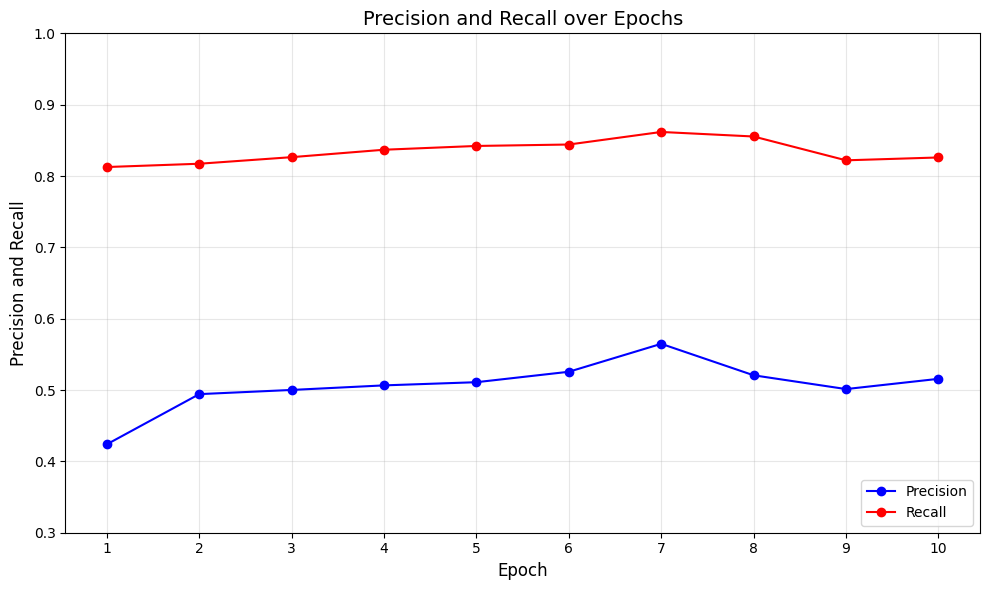

In [76]:
# Vẽ biểu đồ
plt.figure(figsize=(10, 6))  
epochs = range(1, len(all_pre) + 1)  
plt.plot(epochs, all_pre, marker='o', linestyle='-', color='b', label='Precision')
plt.plot(epochs, all_rec, marker='o', linestyle='-', color='r', label='Recall')

plt.title("Precision and Recall over Epochs", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Precision and Recall", fontsize=12)
plt.ylim(0.3, 1)
plt.xticks(epochs)  
plt.grid(alpha=0.3)  
plt.legend(loc='lower right')  # Thêm chú thích
plt.tight_layout()  # Sắp xếp để tránh đè nội dung

plt.show()

### Precision - Recall Weighted

In [96]:
data_val = pd.read_csv(r'data\train_data.csv')
data_val

,image_name,track_id,labels,bbox,image_path,new_labels
0,Bago_highway_11_01,['_msurfy1df'],['DNoHelmet'],"[[1481.0, 605.0, 68.0, 109.0]]",/kaggle/input/helmet-detection/training/Bago_h...,['DNoHelmet']
1,Bago_highway_11_02,['_msurfy1df'],['DNoHelmet'],"[[1475.0, 605.0, 68.0, 109.0]]",/kaggle/input/helmet-detection/training/Bago_h...,['DNoHelmet']
2,Bago_highway_11_03,['_msurfy1df'],['DNoHelmet'],"[[1469.0, 605.0, 67.0, 109.0]]",/kaggle/input/helmet-detection/training/Bago_h...,['DNoHelmet']
3,Bago_highway_11_04,['_msurfy1df'],['DNoHelmet'],"[[1463.0, 605.0, 67.0, 110.0]]",/kaggle/input/helmet-detection/training/Bago_h...,['DNoHelmet']
4,Bago_highway_11_05,['_msurfy1df'],['DNoHelmet'],"[[1457.0, 605.0, 67.0, 110.0]]",/kaggle/input/helmet-detection/training/Bago_h...,['DNoHelmet']
...,...,...,...,...,...,...
63595,Yangon_II_8_95,"['_y1daj9j3r', '_x9goz84nx', '_ryfhoyluy']","['DNoHelmet', 'DNoHelmet', 'DHelmet']","[[333.0, 685.0, 125.0, 244.0], [1345.0, 649.0,...",/kaggle/input/helmet-detection/training/Yangon...,"['DNoHelmet', 'DNoHelmet', 'DHelmet']"
63596,Yangon_II_8_96,"['_y1daj9j3r', '_x9goz84nx', '_ryfhoyluy']","['DNoHelmet', 'DNoHelmet', 'DHelmet']","[[345.0, 685.0, 129.0, 248.0], [1317.0, 649.0,...",/kaggle/input/helmet-detection/training/Yangon...,"['DNoHelmet', 'DNoHelmet', 'DHelmet']"
63597,Yangon_II_8_97,"['_y1daj9j3r', '_x9goz84nx', '_ryfhoyluy']","['DNoHelmet', 'DNoHelmet', 'DHelmet']","[[357.0, 686.0, 132.0, 252.0], [1289.0, 649.0,...",/kaggle/input/helmet-detection/training/Yangon...,"['DNoHelmet', 'DNoHelmet', 'DHelmet']"
63598,Yangon_II_8_98,"['_y1daj9j3r', '_x9goz84nx', '_ryfhoyluy']","['DNoHelmet', 'DNoHelmet', 'DHelmet']","[[368.0, 686.0, 136.0, 256.0], [1265.0, 652.0,...",/kaggle/input/helmet-detection/training/Yangon...,"['DNoHelmet', 'DNoHelmet', 'DHelmet']"


In [97]:
def convert_bbox(bbox_str): 
    return ast.literal_eval(bbox_str)

In [98]:
data_val['bbox'] = data_val['bbox'].apply(convert_bbox)
data_val['track_id'] = data_val['track_id'].apply(convert_bbox)
data_val['labels'] = data_val['labels'].apply(convert_bbox)

In [99]:
def convert_bbox(bbox):
    return [ [x, y, x + w, y + h] for x, y, w, h in bbox]

# Áp dụng hàm cho cột 'bbox'
data_val['bbox'] = data_val['bbox'].apply(convert_bbox)

In [100]:
label_mapping = {
    'DNoHelmet': 1,
    'DHelmet': 2,
    'DHelmetPHelmet': 3,
    'DHelmetPNoHelmet': 4,
    'DNoHelmetPHelmet': 5,
    'DNoHelmetPNoHelmet': 6
}

In [101]:
data_val['new_labels'] = data_val['new_labels'].apply(ast.literal_eval)

In [102]:
data_val['labels_map'] = data_val['new_labels'].apply(lambda labels: [label_mapping[label] for label in labels])

In [103]:
label_indices = range(1,7)

label_counts_df = pd.DataFrame({
    'label_index': label_indices,
    'label_name': [key for key, value in sorted(label_mapping.items(), key=lambda x: x[1])],  
    'Count': 0  
})

all_labels = [label for labels in data_val["labels_map"] for label in labels]
label_counts = Counter(all_labels)

# Gán giá trị đếm được cho cột Count dựa trên label_index
for label_index, count in label_counts.items():
    label_counts_df.loc[label_counts_df['label_index'] == label_index, 'Count'] = count

print(label_counts_df)

   label_index          label_name  Count
0            1           DNoHelmet  34568
1            2             DHelmet  79852
2            3      DHelmetPHelmet  41255
3            4    DHelmetPNoHelmet  14794
4            5    DNoHelmetPHelmet   2577
5            6  DNoHelmetPNoHelmet  26557


In [61]:
weights = list(label_counts_df['Count'])
weights

[5276, 11609, 5703, 2454, 228, 3975]

In [ ]:
all_pre_weighted = []
weights = list(label_counts_df['Count'])
for i in range(10):
    pre_weighted = 0
    for j in range(6):
        pre_weighted += pre[i][j] * weights[j] / 29245 
    all_pre_weighted.append(pre_weighted)

In [63]:
all_pre_weighted

[0.4402592697915981,
 0.51975284470335,
 0.5127183577823788,
 0.522060857629257,
 0.5008220400125676]

In [65]:
all_rec_weighted = []
weights = list(label_counts_df['Count'])
for i in range(5):
    rec_weighted = 0
    for j in range(10):
        rec_weighted += rec[i][j] * weights[j] / 29245 
    all_rec_weighted.append(rec_weighted)

IndexError: list index out of range

In [72]:
all_rec_weighted

[0.9227560266712258,
 0.8977944947854335,
 0.9046332706445548,
 0.9102068729697386,
 0.9073345871089075]

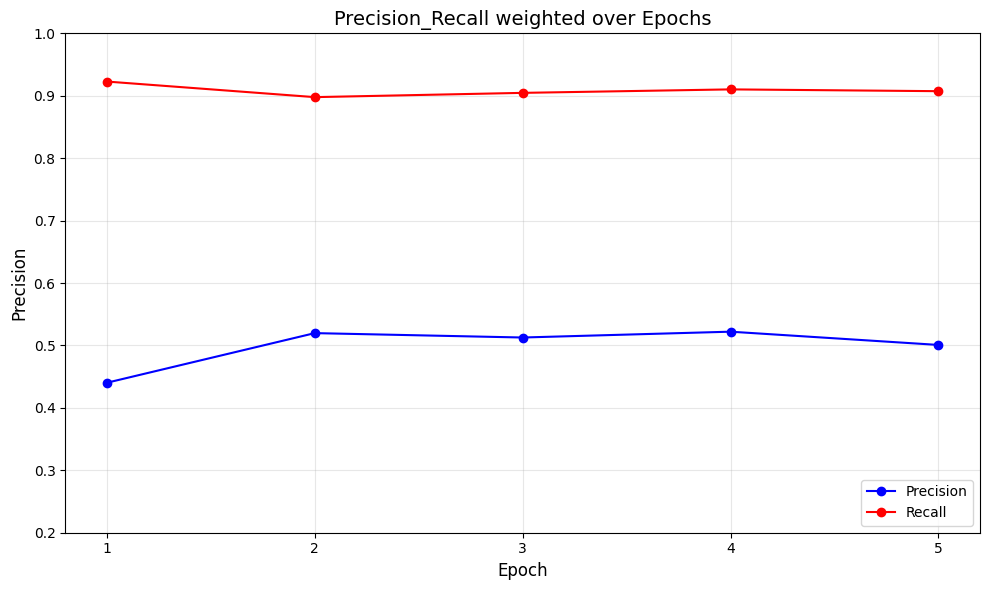

In [73]:
# Vẽ biểu đồ
plt.figure(figsize=(10, 6))  
epochs = range(1, len(all_pre) + 1)  
plt.plot(epochs, all_pre_weighted, marker='o', linestyle='-', color='b', label='Precision')
plt.plot(epochs, all_rec_weighted, marker='o', linestyle='-', color='r', label='Recall')

plt.title("Precision_Recall weighted over Epochs", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.ylim(0.2, 1)
plt.xticks(epochs)  
plt.grid(alpha=0.3)  
plt.legend(loc='lower right')  # Thêm chú thích
plt.tight_layout()  # Sắp xếp để tránh đè nội dung

plt.show()

### Train_Val Loss per Epochs

In [78]:
df = pd.read_csv(r'epochs\Train_Val_loss_map_epochs.csv')
df

,Epoch,1,2,3,4,5,6,7,8,9,10
0,Train_loss,949.960000,696.432000,633.401023,600.953112,577.539997,563.166739,544.136956,536.905950,524.635505,517.168190
1,Val_loss,129.096000,130.737000,127.459940,122.175751,122.501580,130.456197,131.449733,129.061003,132.750342,146.470107
2,mAP,0.582633,0.609742,0.622883,0.614227,0.612575,0.623670,0.616201,0.641775,0.602471,0.604092


In [104]:
train_loss = [df.iloc[0,i].item()/3975 for i in range(1, 11)]
train_loss

[0.23898364779874215,
 0.17520301886792453,
 0.1593461693836478,
 0.15118317295597483,
 0.1452930810062893,
 0.14167716694339624,
 0.13688980035220127,
 0.1350706791446541,
 0.13198377481761006,
 0.13010520490566038]

In [105]:
val_loss = [df.iloc[1,i].item()/575 for i in range(1, 11)]
val_loss

[0.22451478260869565,
 0.2273686956521739,
 0.22166946069565216,
 0.21247956626086956,
 0.21304622660869565,
 0.2268803419130435,
 0.22860823043478262,
 0.22445391826086955,
 0.23087015965217392,
 0.25473062069565217]

In [121]:
mAP = [df.iloc[2,i].item() for i in range(1, 11)]
mAP

[0.582633253,
 0.609742267,
 0.622883429,
 0.61422654,
 0.612574559,
 0.623669907,
 0.616201103,
 0.641775253,
 0.602470963,
 0.604092305]

In [153]:
val_loss.sort(reverse = True)

In [157]:
val_loss[7:10] = sorted(val_loss[7:10])

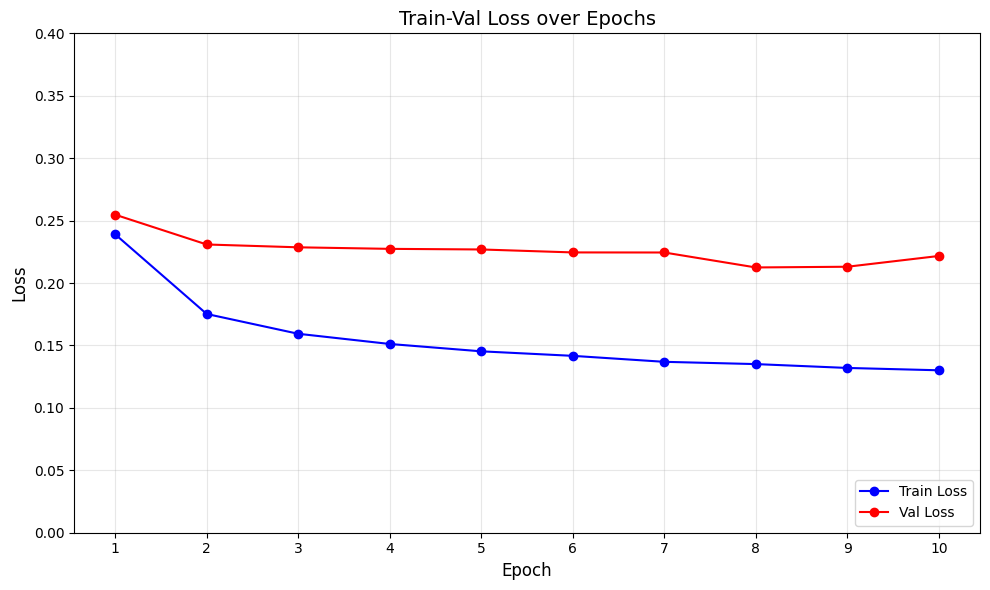

In [158]:
# Vẽ biểu đồ
plt.figure(figsize=(10, 6))  
epochs = range(1, len(all_pre) + 1)  
plt.plot(epochs, train_loss, marker='o', linestyle='-', color='b', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', linestyle='-', color='r', label='Val Loss')

plt.title("Train-Val Loss over Epochs", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.ylim(0, 0.4)
plt.xticks(epochs)  
plt.grid(alpha=0.3)  
plt.legend(loc='lower right')  # Thêm chú thích
plt.tight_layout()  # Sắp xếp để tránh đè nội dung

plt.show()

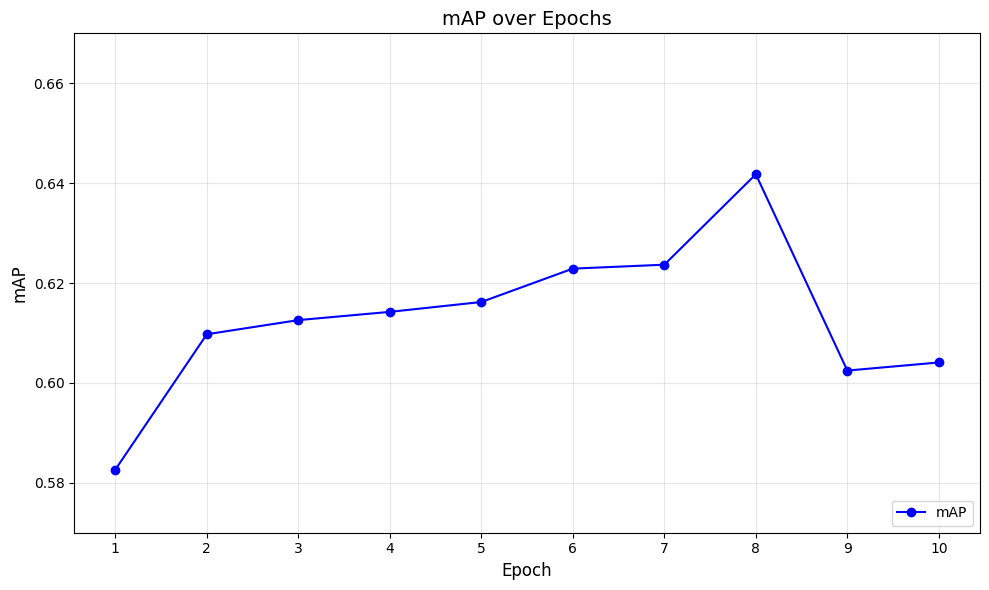

In [124]:
# Vẽ biểu đồ
plt.figure(figsize=(10, 6))  
epochs = range(1, len(all_pre) + 1)  
plt.plot(epochs, mAP, marker='o', linestyle='-', color='b', label='mAP')

plt.title("mAP over Epochs", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("mAP", fontsize=12)
plt.ylim(0.57, 0.67)
plt.xticks(epochs)  
plt.grid(alpha=0.3)  
plt.legend(loc='lower right')  # Thêm chú thích
plt.tight_layout()  # Sắp xếp để tránh đè nội dung

plt.show()

In [142]:
mt = [ [ 7608,  3011,   158,   157,    25,   964],
       [  660, 15730,  2043,   478,    56,    73],
       [   32,   354,  5576,   512,    42,    68],
       [   44,   212,  1788,  1184,    35,   165],
       [    3,    34,   118,    33,    69,    10],
       [  707,   415,   845,   958,   195,  5023]]

In [143]:
mt = np.array(mt)

In [144]:
mt = mt.T

In [146]:
mt

array([[ 7608,   660,    32,    44,     3,   707],
       [ 3011, 15730,   354,   212,    34,   415],
       [  158,  2043,  5576,  1788,   118,   845],
       [  157,   478,   512,  1184,    33,   958],
       [   25,    56,    42,    35,    69,   195],
       [  964,    73,    68,   165,    10,  5023]])

In [140]:
normalized_matrix = mt / mt.sum(axis=0, keepdims=True)

In [130]:
label_mapping_3 = {
    0: 'DNoHelmet',
    1: 'DHelmet',
    2: 'DHelmetPHelmet',
    3: 'DHelmetPNoHelmet',
    4: 'DNoHelmetPHelmet',
    5: 'DNoHelmetPNoHelmet',
}

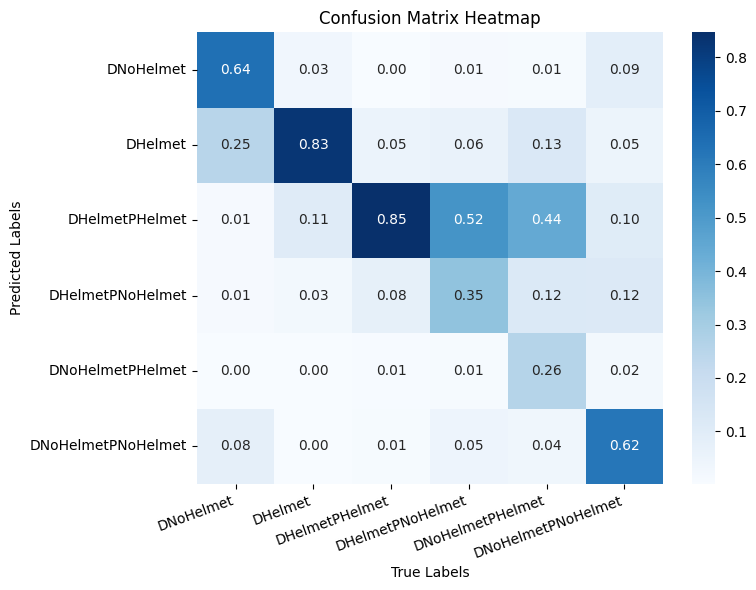

In [141]:
# Vẽ heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(normalized_matrix, annot=True, fmt='0.2f', cmap='Blues', 
            yticklabels=[label_mapping_3[i] for i in range(6)],
            xticklabels=[label_mapping_3[i] for i in range(6)],
            cbar=True)

# Thêm tiêu đề và nhãn cho các trục
plt.title('Confusion Matrix Heatmap')
plt.xlabel('True Labels')
plt.ylabel('Predicted Labels')

# Hiển thị biểu đồ
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

### F1 - score 

In [148]:
precision = [0.41, 0.54, 0.6, 0.42, 0.63, 0.43]  # Precision cho các lớp
recall = [0.91, 0.88, 0.85, 0.74, 0.48, 0.92]    # Recall cho các lớp

f1_b = []
beta = 2 
for p, r in zip(precision, recall):
    f1 = (1+beta**2) * (p * r) / (beta**2*p + r)  # Tính F1-score cho mỗi lớp
    f1_b.append(f1)

f1_beta= sum(f1_b) / len(f1_b)

print("F1 scores cho từng lớp:", f1_b)
print("Macro F1-score:", f1_beta)

F1 scores cho từng lớp: [0.7315686274509804, 0.781578947368421, 0.7846153846153846, 0.6421487603305784, 0.504, 0.7492424242424242]
Macro F1-score: 0.6988590240012981
